In [3]:
!pip install yfinance


In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [5]:
ticker = ['AAPL', 'NVDA', 'AMZN', 'META']
start_date = '2020-12-31'
end_date = '2025-12-31'

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
df.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,META,NVDA
Date,,,,
2020-12-31,129.046646,162.846497,271.265137,13.018391
2021-01-04,125.856712,159.331497,267.074402,13.076723
2021-01-05,127.412766,160.925507,269.090332,13.367157
2021-01-06,123.123856,156.919006,261.483459,12.579124
2021-01-07,127.325218,158.108002,266.875793,13.306581


<Figure size 1200x600 with 0 Axes>

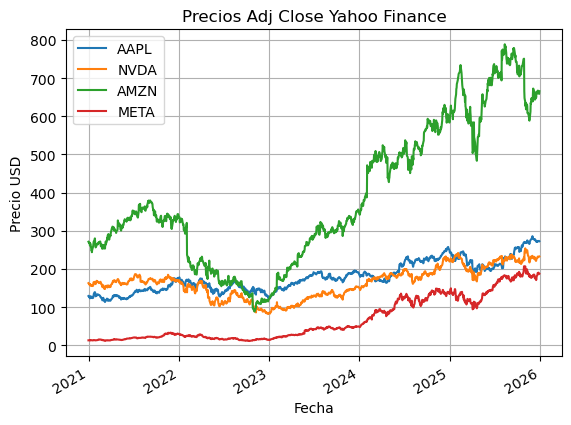

In [6]:
plt.figure(figsize=(12, 6))
df.plot()
plt.title('Precios Adj Close Yahoo Finance')
plt.xlabel('Fecha')
plt.ylabel('Precio USD')
plt.legend(ticker)
plt.grid()
plt.show()

In [7]:
ticker = ['AAPL', 'NVDA', 'AMZN', 'META', '^GSPC']

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False
)['Adj Close']


[*********************100%***********************]  5 of 5 completed


In [8]:
log_returns = np.log(df / df.shift(1))
log_returns = log_returns.dropna()

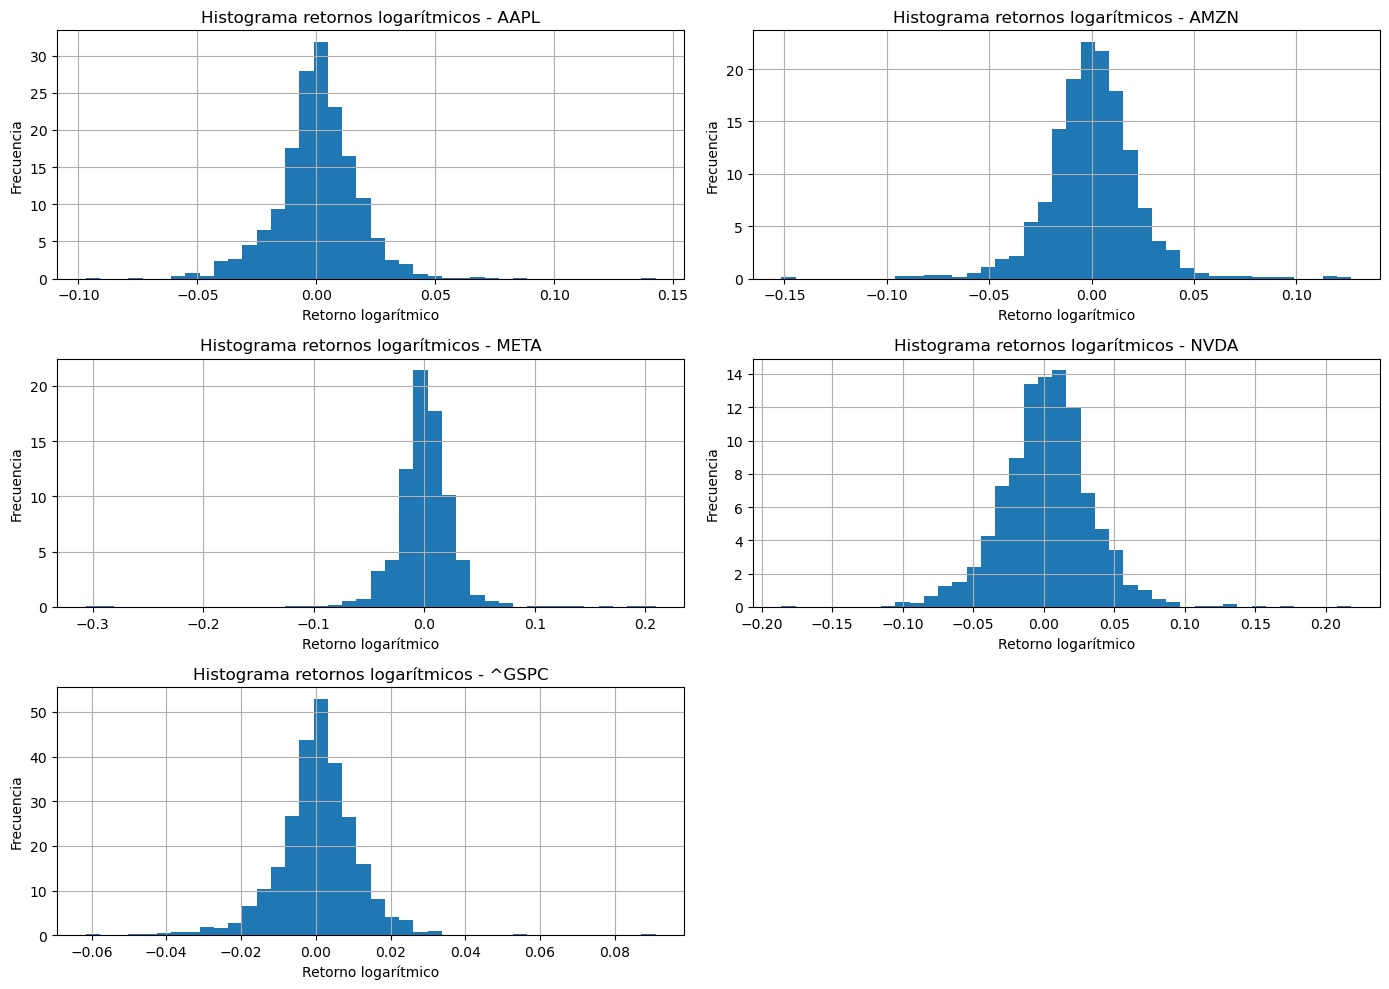

In [9]:

plt.figure(figsize=(14, 10))

for i, col in enumerate(log_returns.columns, 1):
    plt.subplot(3, 2, i)
    plt.hist(log_returns[col], bins=40, density=True)
    plt.title(f'Histograma retornos logarítmicos - {col}')
    plt.xlabel('Retorno logarítmico')
    plt.ylabel('Frecuencia')
    plt.grid(True)

plt.tight_layout()
plt.show()


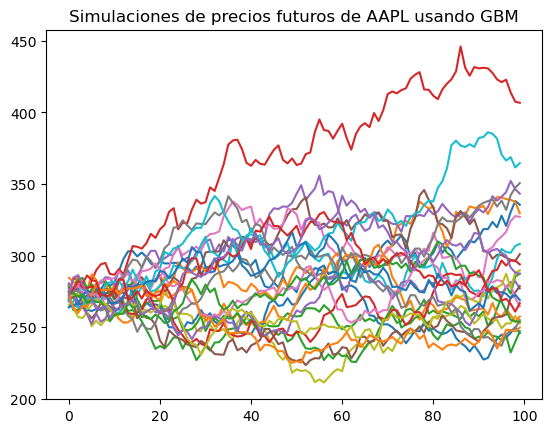

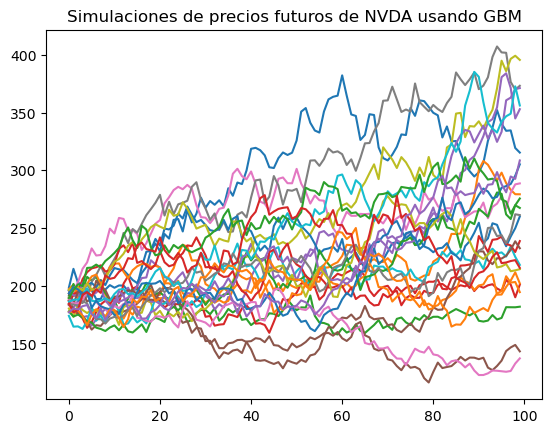

In [15]:
#Punto 3 Modelos de Drift y choque aleatorio 

retornosapple= df['AAPL'].pct_change().dropna()
returnosnvda= df['NVDA'].pct_change().dropna()

media_apple = retornosapple.mean()
desviacion_apple = retornosapple.std()

media_nvda = returnosnvda.mean()
desviacion_nvda = returnosnvda.std()

S0= df['AAPL'].iloc[-1]
S0E= df['NVDA'].iloc[-1]
Horizonte=100
Realizaciones=25
dt= 1 

for i in range(Realizaciones):
    epsilon= np.random.normal(0,1,Horizonte)
    expp=(media_apple - 0.5 * desviacion_apple**2)*dt + desviacion_apple * np.sqrt(dt) * epsilon
    camino= S0 * np.exp(np.cumsum(expp))
    plt.plot(camino)

plt.title('Simulaciones de precios futuros de AAPL usando GBM')
plt.show()


for i in range(Realizaciones):
    epsilon= np.random.normal(0,1,Horizonte)
    expp=(media_nvda - 0.5 * desviacion_nvda**2)*dt + desviacion_nvda * np.sqrt(dt) * epsilon
    camino= S0E * np.exp(np.cumsum(expp))
    plt.plot(camino)

plt.title('Simulaciones de precios futuros de NVDA usando GBM')
plt.show()


In [16]:
newtick = ['AAPL', 'NVDA', 'AMZN', 'META']
start_date = '2024-12-31'
end_date = '2025-12-31'

df25 = yf.download(newtick, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
df25.head()


retornos_log_appl= np.log(df25['AAPL'] / df25['AAPL'].shift(1)).dropna()

media_apple_año= retornos_log_appl.mean() * 252
sigma_apple_año= retornos_log_appl.std() * np.sqrt(252)
S0= df25['AAPL'].iloc[-1]
T=252
N=100
dt=1/252

precios_finales= []

for i in range(N):
    epsilon= np.random.normal(0,1,T) 
    exponent=(media_apple_año - 0.5 * sigma_apple_año**2) * dt + sigma_apple_año * np.sqrt(dt) * epsilon
    path= S0 * np.exp(np.cumsum(exponent))
    precios_finales.append(path[-1])

precios_finales = np.array(precios_finales)


[*********************100%***********************]  4 of 4 completed


In [18]:
#Simulacion de Nvda

retornos_log_nvda= np.log(df25['NVDA'] / df25['NVDA'].shift(1)).dropna()

media_nvda_año= retornos_log_nvda.mean() * 252
sigma_nvda_año= retornos_log_nvda.std() * np.sqrt(252)


S0nvda= df25['NVDA'].iloc[-1]
Tnvda=252
Nnvda=100
dtnvda=1/252

precios_finales_nvda= []

for i in range(Nnvda):
    epsilon= np.random.normal(0,1,Tnvda) 
    exponent=(media_nvda_año - 0.5 * sigma_nvda_año**2) * dtnvda + sigma_nvda_año * np.sqrt(dtnvda) * epsilon
    path= S0nvda * np.exp(np.cumsum(exponent))
    precios_finales_nvda.append(path[-1])

precios_finales_nvda = np.array(precios_finales_nvda)




In [19]:
#Intervalo de confianza al 95%

low= np.percentile(precios_finales, 2.5)
high= np.percentile(precios_finales, 97.5)

print("IC 95% APPLE: ", low, " - ", high)

#Intervalo de confianza al 95% NVDA

low_nvda= np.percentile(precios_finales_nvda, 2.5)
high_nvda= np.percentile(precios_finales_nvda, 97.5)

print("IC 95% NVDA: ", low_nvda, " - ", high_nvda)



IC 95% APPLE:  163.86178483801933  -  532.5692322152481
IC 95% NVDA:  95.53691397432412  -  611.4817608267082
